(debug-tracing)=

# Debugging and Tracing

The {func}`~.build` function transforms an annotated circuit into a template circuit and samplex pair.
In a complex circuit it can be hard to tell which box in the original circuit corresponds to which
barriers in the template, or which nodes in the samplex DAG.

Samplomatic provides two complementary tracing tools:

- **Barrier labels**: every barrier in the template circuit carries a label encoding its origin.
  These are always present regardless of whether `debug=True` is set.
- **Trace info on samplex nodes**: when {func}`~.build` is called with `debug=True`, every samplex
  node carries a {class}`~.TraceInfo` object linking it back to the box or boxes that produced it.

Both tools are most useful when boxes carry a {class}`~.Tag` annotation, which attaches a `ref` 
string to the box. Alternatively, {class}`~.InjectNoise` references are also attached.

In [1]:
# Without this cell, plotly outputs do not appear in the docs. We hide this cell from itself being
# rendered in the docs by editing its metadata to contain the tags ["remove-input", "remove-output"]
import plotly.io as pio

pio.renderers.default = "sphinx_gallery"

## Tagging boxes

A {class}`~.Tag` annotation attaches a `ref` string to a box. The `ref` then appears in barrier
labels and in trace info on samplex nodes.

The example circuit below has three boxes: two tagged CX boxes on disjoint qubit pairs, and an
untagged right-dressed measurement box. The second CX box also carries an {class}`~.InjectNoise`
annotation — both its `tag` ref and its noise `ref` will appear in the barrier labels. The two CX
boxes cover different qubits, which enables the samplex optimizer to merge their propagation nodes
into shared nodes — as we will see in the trace info section.

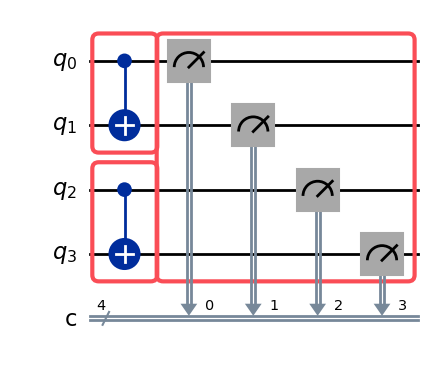

In [2]:
from qiskit.circuit import QuantumCircuit

from samplomatic import InjectNoise, Tag, Twirl, build

circuit = QuantumCircuit(4, 4)

with circuit.box([Twirl(), Tag("cx_ab")]):
    circuit.cx(0, 1)

with circuit.box([Twirl(), InjectNoise("cx_noise"), Tag("cx_cd")]):
    circuit.cx(2, 3)

with circuit.box([Twirl(), Tag("meas_box")]):
    circuit.measure(range(4), range(4))

circuit.draw("mpl")

## Barrier labels in the template circuit

Calling {func}`~.build` on the circuit above produces a template whose barriers carry identifying
labels. Each label has the form `{side}{scope}@{key=value&...}` where:

- **Side**: `L` = left-dressing boundary, `M` = inner box content boundary, `R` = right-dressing
  boundary.
- **Scope**: an integer index (or underscore-separated list for nested boxes) distinguishing multiple
  boxes at the same nesting level.
- **Annotations**: a `@`-prefixed, `&`-separated list of `key=value` pairs derived from the box's
  annotations. The `tag` key comes from a {class}`~.Tag` annotation and `inject_noise` from an
  {class}`~.InjectNoise` annotation.

Barriers from untagged boxes carry only the side and scope (e.g. `L2`), with no `@` suffix.

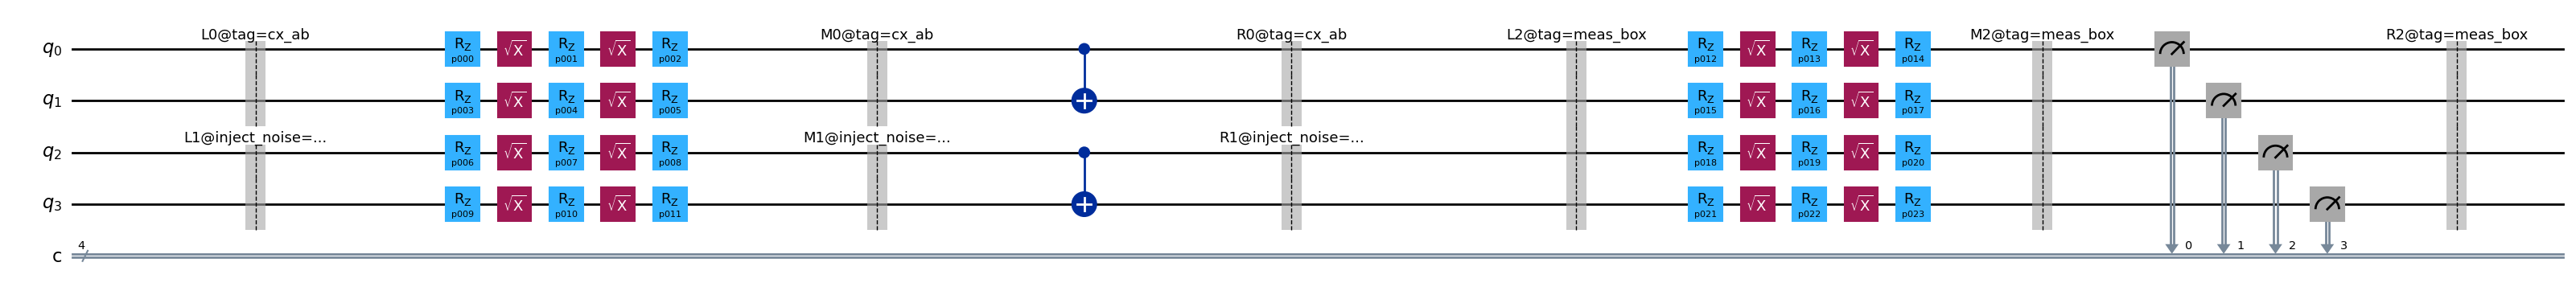

In [3]:
template, samplex = build(circuit)
template.draw("mpl", fold=100, barrier_label_len=10)

The barrier labels can also be extracted programmatically:

In [4]:
barrier_labels = [instr.operation.label for instr in template if instr.operation.name == "barrier"]
barrier_labels

['L0@tag=cx_ab',
 'M0@tag=cx_ab',
 'R0@tag=cx_ab',
 'L1@inject_noise=cx_noise&tag=cx_cd',
 'M1@inject_noise=cx_noise&tag=cx_cd',
 'R1@inject_noise=cx_noise&tag=cx_cd',
 'L2@tag=meas_box',
 'M2@tag=meas_box',
 'R2@tag=meas_box']

## Trace info on samplex nodes

Passing `debug=True` to {func}`~.build` attaches trace information to every samplex node. Each
node's {attr}`~.Node.trace_info` attribute is a {class}`~.TraceInfo` object whose `trace_refs`
dictionary maps annotation keys (e.g. `"tag"`, `"inject_noise"`) to sets of ref strings. Nodes
without a corresponding box annotation have `trace_info=None`.

When {meth}`~.Samplex.draw` is called on a debug-built samplex, hovering over any node in the
interactive graph reveals its `trace_refs` inside of the hover tooltip.

In [5]:
template, samplex = build(circuit, debug=True)
samplex.draw()

Trace info can also be inspected programmatically. Notice that some nodes carry refs from both
`'cx_ab'` and `'cx_cd'` — the samplex optimizer merged their parallel propagation nodes because
the two boxes cover disjoint qubits and share a common predecessor from the right-dressed
measurement box's emission.

In [6]:
for node in samplex.graph.nodes():
    if node.trace_info is not None:
        tags = node.trace_info.trace_refs.get("tag", set())
        merged = " ← merged" if len(tags) > 1 else ""
        print(f"{type(node).__name__:40s}  tags={tags}{merged}")

TwirlSamplingNode                         tags={'meas_box'}
TwirlSamplingNode                         tags={'cx_cd'}
InjectNoiseNode                           tags={'cx_cd'}
CollectZ2ToOutputNode                     tags={'cx_cd'}
CombineRegistersNode                      tags={'cx_cd'}
CollectTemplateValues                     tags={'cx_cd'}
TwirlSamplingNode                         tags={'cx_ab'}
CombineRegistersNode                      tags={'cx_ab', 'cx_cd'} ← merged
CollectTemplateValues                     tags={'cx_ab', 'cx_cd'} ← merged


To find all nodes that originate from a specific box, filter by the `"tag"` key:

In [7]:
tag_ref = "cx_ab"
matching_nodes = [
    node
    for node in samplex.graph.nodes()
    if node.trace_info is not None and tag_ref in node.trace_info.trace_refs.get("tag", set())
]

print(f"Nodes originating from box '{tag_ref}':")
for node in matching_nodes:
    print(f"  {type(node).__name__}")

Nodes originating from box 'cx_ab':
  TwirlSamplingNode
  CombineRegistersNode
  CollectTemplateValues


## Understanding the samplex DAG

The samplex returned by {func}`~.build` is a directed acyclic graph (DAG) where **edges denote
register dependency**: an edge from node A to node B means B must wait for A to have acted on
the shared virtual registers before B is allowed to act. This is not a temporal ordering like
the DAG of a quantum circuit — instead the graph flows from nodes responsible for generating
randomizations to nodes responsible for synthesizing them as outputs.

There are three node types, each with a distinct visual style in the interactive plot:

| Shape | Color | Type | Role |
|---|---|---|---|
| Star | Red | {class}`~.SamplingNode` | Instantiates new virtual registers from a distribution or input |
| Circle | Green | {class}`~.EvaluationNode` | Transforms, combines, or propagates virtual registers |
| Bowtie | Blue / Purple | {class}`~.CollectionNode` | Reads registers and writes to `sample()` outputs |

Execution proceeds in three phases: all sampling nodes run first (in parallel), evaluation nodes
run next in topological order (parallel within each generation), and collection nodes run last
(in parallel). The graphviz layout reflects this — sampling nodes appear at the top, collection
nodes at the bottom.

## Reading hover tooltips

Every node in the interactive visualization shows a tooltip when hovered. The tooltip contains:

- **Node class name** and its integer graph index.
- **Register manifests**: which registers the node instantiates, reads from, writes to, and
  removes. These tell you how data flows between nodes.
- **Node-specific details**: the distribution type for sampling nodes, the operand for
  multiplication nodes, the template parameter indices for collection nodes, etc.
- **Trace refs** (only when `debug=True`): the annotation keys and ref strings linking the
  node back to its originating box(es).

Clicking the plot and then hovering over individual nodes is the fastest way to understand what
a given node does without reading source code.

## Orienting in a samplex

Before diving into the visualization, `print(samplex)` gives a quick text summary of the node
count, required inputs, and promised outputs.

In [8]:
template, samplex = build(circuit)
print(samplex)

Samplex(<15 nodes>)
  Inputs:
  - 'pauli_lindblad_maps.cx_noise' <PauliLindbladMap>: A PauliLindblad map acting on 2
      qubits, with 'num_terms_cx_noise' terms.

  Outputs:
    * 'measurement_flips.c' <bool['num_randomizations', 1, 4]>: Bit-flip corrections for
        measurement twirling.
    * 'parameter_values' <float32['num_randomizations', 24]>: Parameter values valid for an
        associated template circuit.
    * 'pauli_signs' <bool['num_randomizations', 1]>: Signs from sampled Pauli Lindblad
        maps, where boolean values represent the parity of the number of non-trivial factors in the
        sampled error that arise from negative rates. In other words, in order to implement basic
        PEC, the sign used to correct expectation values should be ``(-1)**bool_value``. The order
        matches the iteration order of boxes in the original circuit with noise injection
        annotations.



## Inspecting registers with `keep_registers`

Passing `keep_registers=True` to {meth}`~.Samplex.sample` retains the intermediate
{class}`~.VirtualRegister` objects that are live at the end of sampling, storing them in
`outputs.metadata["registers"]`. Each register is a 2D array (shape
`(num_subsystems, num_randomizations)`, with possible trailing gate-shape dimensions) of virtual
group elements.

This is useful for verifying that virtual gates were combined correctly, or for inspecting the
raw Pauli or unitary samples before they are synthesized into rotation angles.

In [9]:
from qiskit.quantum_info import PauliLindbladMap

outputs = samplex.sample(
    {"pauli_lindblad_maps.cx_noise": PauliLindbladMap.identity(2)},
    num_randomizations=3,
    keep_registers=True,
)
for name, reg in outputs.metadata["registers"].items():
    print(f"{name}: type={reg.TYPE.value}, shape={reg.virtual_gates.shape}")

lhs_0: type=pauli, shape=(4, 3)
rhs_0: type=pauli, shape=(4, 3)
lhs_2: type=pauli, shape=(2, 3)
rhs_2: type=pauli, shape=(2, 3)
inject_noise_4: type=pauli, shape=(2, 3)
sign_4: type=z2, shape=(1, 3)
lhs_6: type=pauli, shape=(2, 3)
rhs_6: type=pauli, shape=(2, 3)
z2_collect_1: type=z2, shape=(4, 3)
collect_7: type=u2, shape=(4, 3, 2, 2)
collect_5: type=u2, shape=(2, 3, 2, 2)
collect_9: type=u2, shape=(2, 3, 2, 2)


You can view the contents of the end-state of a particular register. In the particular example below, the register has type {class}`~.PauliRegister`; see the API documentation for details about the storage format.

In [10]:
print("lhs_2:", outputs.metadata["registers"]["lhs_2"])
outputs.metadata["registers"]["lhs_2"].virtual_gates

lhs_2: PauliRegister(<2, 3>)


array([[3, 2, 3],
       [1, 1, 2]], dtype=uint8)

## How samplex nodes map to template parameters

The `outputs["parameter_values"]` array returned by {meth}`~.Samplex.sample` has shape
`(num_randomizations, N)` where `N` matches `len(template.parameters)`. Each column corresponds
to one parameter in the template circuit — the i-th column fills in `template.parameters[i]`.

The {class}`~.CollectTemplateValues` collection nodes are the link between virtual registers and
template parameters. Each such node holds index information that records which columns of the 
output array itwrites to. This makes it possible to trace which virtual-gate subsystems drive 
which template parameters.

See the {doc}`samplex_io` guide for how to bind the sampled parameter values to the template
circuit and run experiments.

In [ ]:
from samplomatic.samplex.nodes import CollectTemplateValues

template, samplex = build(circuit, debug=True)
for node in samplex.graph.nodes():
    if isinstance(node, CollectTemplateValues):
        tags = node.trace_info.trace_refs.get("tag", set()) if node.trace_info else set()
        print(f"tags={tags}  →  template param indices: {node.template_idxs.tolist()}")

tags={'cx_cd'}  →  template param indices: [[6, 7, 8], [9, 10, 11]]
tags={'cx_ab', 'cx_cd'}  →  template param indices: [[12, 13, 14], [15, 16, 17], [18, 19, 20], [21, 22, 23]]
tags=set()  →  template param indices: [[0, 1, 2], [3, 4, 5]]


## Automatic tagging via the transpiler

When using {func}`~.generate_boxing_pass_manager`, the `add_tags` parameter automatically adds
{class}`~.Tag` annotations to all boxes. Three modes are available:

- **`"unique_instance"`**: assigns sequential refs `t0`, `t1`, ... to boxes in circuit order.
  Every box gets a distinct ref regardless of its structure.
- **`"unique_box"`**: computes a structural hash of each box's content and assigns the same ref to
  all structurally equivalent boxes. Useful for grouping boxes by type rather than position.
- **`"noise_ref"`**: copies the `ref` from each box's {class}`~.InjectNoise` annotation, and only
  tags boxes that have one. Useful when meaningful noise refs already exist.

The example below applies `"unique_instance"` and `"unique_box"` to a circuit whose two CX boxes
are structurally equivalent. With `"unique_instance"` each gets a distinct ref, while with
`"unique_box"` they share one.

In [12]:
from samplomatic.transpiler import generate_boxing_pass_manager

base_circuit = QuantumCircuit(3)
base_circuit.cx(0, 1)
base_circuit.cx(1, 2)
base_circuit.measure_all()

# unique_instance: every box gets a distinct tag ref
pm = generate_boxing_pass_manager(add_tags="unique_instance")
boxed = pm.run(base_circuit)
template, _ = build(boxed)

print("unique_instance barrier labels:")
for instr in template:
    if instr.operation.name == "barrier" and instr.operation.label:
        print(f"  {instr.operation.label}")

unique_instance barrier labels:
  L0@tag=t0
  M0@tag=t0
  R0@tag=t0
  L1@tag=t1
  M1@tag=t1
  R1@tag=t1
  L2@tag=t2
  M2@tag=t2
  R2@tag=t2
